# Statistics-Guided PCA Pipeline — Chest X-Ray Pneumonia (128×128)

**Pipeline:**
1. Compute 5 discriminative statistics per image (from Fisher ratio analysis at 128×128)
2. PCA on statistics — identify statistical PCs representing the discriminative signal
3. Pixel PCA on 128×128 images — fit up to 200 image PCs
4. Weighted correlation of each image PC with the statistical PCs
5. Keep image PCs above correlation threshold (0.3)
6. Reconstruct each image from kept PCs only
7. Compare original vs reconstruction — Normal and Pneumonia

## 1. Imports

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from skimage.exposure import equalize_adapthist
from skimage.filters import gaussian as sk_gaussian
from scipy.ndimage import uniform_filter, gaussian_filter
from scipy.stats import pearsonr
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print('Imports done')

Imports done


## 2. Helper Functions

In [4]:
def apply_smooth_region_filter(image, window=9):
    mean_sq        = uniform_filter(image**2, size=window)
    sq_mean        = uniform_filter(image,    size=window)**2
    local_std      = np.sqrt(np.clip(mean_sq - sq_mean, 0, None)).astype(np.float32)
    s_rng          = local_std.max() - local_std.min()
    local_std_norm = (local_std - local_std.min()) / (s_rng + 1e-8)
    smooth_mask    = gaussian_filter(1.0 - local_std_norm, sigma=1.0)
    filtered       = image * smooth_mask
    f_rng          = filtered.max() - filtered.min()
    return ((filtered - filtered.min()) / (f_rng + 1e-8)).astype(np.float32)


def norm_batch(X):
    mn = X.min(axis=(1,2), keepdims=True)
    mx = X.max(axis=(1,2), keepdims=True)
    return (X - mn) / (mx - mn + 1e-8)


print('Helper functions defined')

Helper functions defined


## 3. Load and Preprocess at 128×128

In [5]:
DIM         = 128
NUM_CLASSES = 2
TRAIN_DIR   = '/mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/chest_xray/train'
TEST_DIR    = '/mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/chest_xray/test'


def load_data(data_dir, dim=DIM):
    ds = tf.keras.utils.image_dataset_from_directory(
        data_dir, labels='inferred', label_mode='int',
        image_size=(dim, dim), batch_size=None, shuffle=False
    )
    x = np.array([item[0].numpy() for item in ds])
    y = np.array([item[1].numpy() for item in ds])
    return x, y


def to_gray(images_rgb, dim=DIM):
    out = np.empty((len(images_rgb), dim, dim), dtype=np.float32)
    for i, img in enumerate(images_rgb):
        gray   = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_RGB2GRAY)
        out[i] = gray / 255.0
    return out


def preprocess_xray(img, dim=DIM, window=9):
    img  = equalize_adapthist(img, clip_limit=0.03).astype(np.float32)
    h, w = img.shape
    pad_h = int(h * 0.10); pad_w = int(w * 0.08)
    img   = img[pad_h:h-pad_h, pad_w:w-pad_w]
    img   = cv2.resize(img, (dim, dim), interpolation=cv2.INTER_AREA)
    img   = sk_gaussian(img, sigma=0.5).astype(np.float32)
    if img.max() > 1e-8:
        img = img / img.max()
    img   = apply_smooth_region_filter(img, window=window)
    return img


print('Loading data at 128×128...')
x_train_raw, y_train_int = load_data(TRAIN_DIR)
x_test_raw,  y_test_int  = load_data(TEST_DIR)
print(f'Train: {len(x_train_raw)} | Test: {len(x_test_raw)}')

x_train_gray = to_gray(x_train_raw); del x_train_raw
x_test_gray  = to_gray(x_test_raw);  del x_test_raw

print('Preprocessing...')
x_train = np.zeros((len(x_train_gray), DIM, DIM), dtype=np.float32)
for i in tqdm(range(len(x_train_gray)), desc='Train'):
    x_train[i] = preprocess_xray(x_train_gray[i])

x_test = np.zeros((len(x_test_gray), DIM, DIM), dtype=np.float32)
for i in tqdm(range(len(x_test_gray)), desc='Test'):
    x_test[i] = preprocess_xray(x_test_gray[i])

del x_train_gray, x_test_gray

y_train = to_categorical(y_train_int, num_classes=NUM_CLASSES)
y_test  = to_categorical(y_test_int,  num_classes=NUM_CLASSES)
y_ints  = y_train_int

print(f'x_train : {x_train.shape}')
print(f'Normal  : {(y_ints==0).sum()}  Pneumonia: {(y_ints==1).sum()}')

Loading data at 128×128...
Found 5216 files belonging to 2 classes.


W0000 00:00:1785351819.466443    9487 gpu_device.cc:2431] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1785351819.470635    9487 gpu_device.cc:2431] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1785351819.710482    9487 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5199 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0
2026-07-29 12:03:48.698027: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Found 624 files belonging to 2 classes.


2026-07-29 12:03:57.529973: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-07-29 12:03:59.177878: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Train: 5216 | Test: 624
Preprocessing...


Test: 100%|██████████| 624/624 [00:01<00:00, 434.87it/s]

x_train : (5216, 128, 128)
Normal  : 1341  Pneumonia: 3875


## 4. Compute 5 Discriminative Statistics per Image

Statistics chosen from Fisher ratio analysis at 128×128:
- **low_high_ratio** (Fisher=0.87) — strongest signal, pneumonia has more low-frequency power
- **lower_std**      (Fisher=0.64) — texture variation in lower lobes
- **lower_mean**     (Fisher=0.67) — consolidation increases lower lobe brightness
- **global_mean**    (Fisher=0.30) — overall brightness increase
- **dc_power**       (Fisher=0.30) — DC component / overall energy

lr_asymmetry dropped — t-SNE showed no consistent directional gradient.

In [6]:
from skimage.feature import graycomatrix, graycoprops

def compute_5_statistics(image):
    """
    Computes the 5 discriminative statistics for one 128×128 chest X-ray image.

    Returns
    -------
    features : (5,) float32
    names    : list of 5 strings
    """
    H, W  = image.shape
    lower = image[H//2:, :]   # lower half

    # 1 — lower_mean
    lower_mean = float(lower.mean())

    # 2 — low_high_ratio (Fourier domain)
    F         = np.fft.fftshift(np.fft.fft2(image))
    power     = np.abs(F)**2
    freqs     = np.fft.fftshift(np.fft.fftfreq(H))
    U, V      = np.meshgrid(np.fft.fftshift(np.fft.fftfreq(W)), freqs)
    R         = np.sqrt(U**2 + V**2)
    low_high_ratio = float(power[R < 0.07].mean() /
                           (power[R >= 0.15].mean() + 1e-8))

    # 3 — lower_std
    lower_std = float(lower.std())

    # 4 — global_mean
    global_mean = float(image.mean())

    # 5 — dc_power
    dc_power = float(np.abs(F[H//2, W//2])**2 / (image.size**2 + 1e-8))

    features = np.array([lower_mean, low_high_ratio, lower_std,
                         global_mean, dc_power], dtype=np.float32)
    names    = ['lower_mean', 'low_high_ratio', 'lower_std',
                'global_mean', 'dc_power']
    return features, names


print('Extracting statistics for all training images...')
sample_feat, STAT_NAMES = compute_5_statistics(x_train[0])
print(f'Statistics: {STAT_NAMES}')

X_stats = np.zeros((len(x_train), 5), dtype=np.float32)
for i in tqdm(range(len(x_train)), desc='Statistics'):
    X_stats[i], _ = compute_5_statistics(x_train[i])

print(f'Statistics matrix shape: {X_stats.shape}')

# Quick Fisher ratio check — should match the 128x128 results from your analysis
print(f'\nFisher ratio check (128×128):')
print(f'{"Statistic":>18}  {"Fisher":>8}  {"Normal mean":>12}  {"Pneumonia mean":>14}')
print('-' * 60)
for i, name in enumerate(STAT_NAMES):
    vals_n = X_stats[y_ints==0, i]
    vals_p = X_stats[y_ints==1, i]
    fisher = (vals_p.mean()-vals_n.mean())**2 / \
             (vals_p.std()**2+vals_n.std()**2+1e-8)
    print(f'{name:>18}  {fisher:8.4f}  '
          f'{vals_n.mean():12.4f}  {vals_p.mean():14.4f}')

Extracting statistics for all training images...
Statistics: ['lower_mean', 'low_high_ratio', 'lower_std', 'global_mean', 'dc_power']


Statistics: 100%|██████████| 5216/5216 [00:01<00:00, 3204.77it/s]

Statistics matrix shape: (5216, 5)

Fisher ratio check (128×128):
         Statistic    Fisher   Normal mean  Pneumonia mean
------------------------------------------------------------
        lower_mean    0.3230        0.3857          0.4225
    low_high_ratio    0.8599     6060.6152       9563.3047
         lower_std    0.1197        0.2124          0.2219
       global_mean    0.0963        0.3851          0.3992
          dc_power    0.1048        0.1489          0.1609


## 5. Statistical PCA

PCA on the (N, 5) statistics matrix.
The top statistical PCs represent the dominant discriminative axes in statistics space:
- **Stat PC1** — expected: consolidation brightness/opacity axis (lower_mean + lower_std + global_mean)
- **Stat PC2** — expected: frequency content axis (low_high_ratio dominant)

Statistical PCA — variance explained:
  Stat PC1:  70.12%   cumulative:  70.12%  <-- keep
  Stat PC2:  19.27%   cumulative:  89.39%  <-- keep
  Stat PC3:   7.97%   cumulative:  97.37%  <-- keep
  Stat PC4:   2.56%   cumulative:  99.93%  
  Stat PC5:   0.07%   cumulative: 100.00%  

Using top 3 statistical PCs (95% variance in statistics space)

Stat PC loadings (which statistics drive each PC):
                  StatPC1  StatPC2  StatPC3
----------------------------------------------
      lower_mean   +0.502   -0.130   -0.165
  low_high_ratio   +0.417   +0.333   +0.845
       lower_std   +0.257   +0.841   -0.462
     global_mean   +0.503   -0.293   -0.171
        dc_power   +0.506   -0.282   -0.128


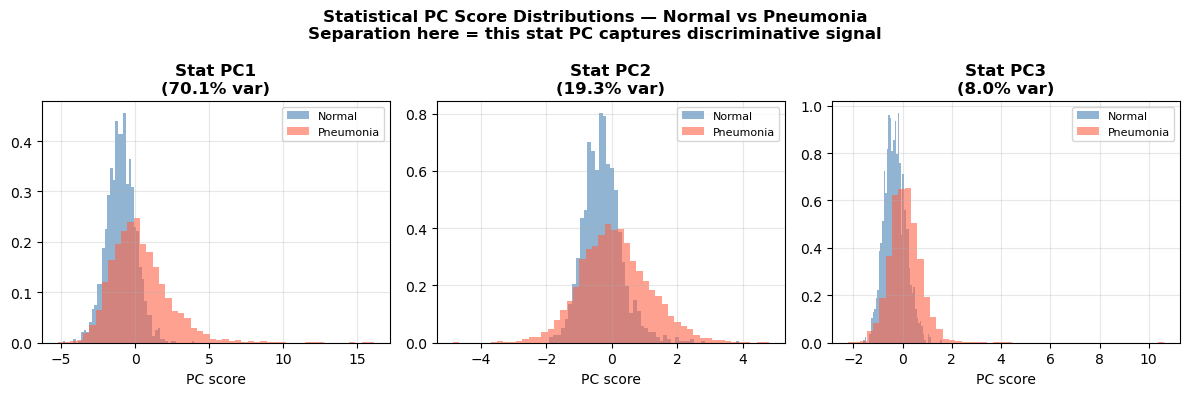

In [7]:
# Standardise — critical since statistics have very different scales
scaler         = StandardScaler()
X_stats_scaled = scaler.fit_transform(X_stats)   # (N, 5) mean=0 std=1

# Fit PCA on statistics
pca_stats   = PCA(n_components=5, random_state=42)
X_stat_pca  = pca_stats.fit_transform(X_stats_scaled)   # (N, 5)

cumvar_stats = np.cumsum(pca_stats.explained_variance_ratio_) * 100
n_stat_pcs   = int(np.argmax(cumvar_stats >= 95)) + 1

print('Statistical PCA — variance explained:')
for i, var in enumerate(pca_stats.explained_variance_ratio_):
    keep = '<-- keep' if i < n_stat_pcs else ''
    print(f'  Stat PC{i+1}: {var*100:6.2f}%   cumulative: {cumvar_stats[i]:6.2f}%  {keep}')

print(f'\nUsing top {n_stat_pcs} statistical PCs (95% variance in statistics space)')

# Show loadings — which statistics drive each stat PC
print(f'\nStat PC loadings (which statistics drive each PC):')
print(f'{"":>16}', end='')
for i in range(n_stat_pcs):
    print(f'  StatPC{i+1}', end='')
print()
print('-' * (16 + n_stat_pcs * 10))
for j, name in enumerate(STAT_NAMES):
    print(f'{name:>16}', end='')
    for i in range(n_stat_pcs):
        print(f'  {pca_stats.components_[i,j]:+7.3f}', end='')
    print()

# Plot stat PC score distributions per class
fig, axes = plt.subplots(1, n_stat_pcs, figsize=(4*n_stat_pcs, 4))
if n_stat_pcs == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    ax.hist(X_stat_pca[y_ints==0, i], bins=50, color='steelblue',
            alpha=0.6, density=True, label='Normal')
    ax.hist(X_stat_pca[y_ints==1, i], bins=50, color='tomato',
            alpha=0.6, density=True, label='Pneumonia')
    ax.set_title(f'Stat PC{i+1}\n({pca_stats.explained_variance_ratio_[i]*100:.1f}% var)',
                 fontweight='bold')
    ax.set_xlabel('PC score'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('Statistical PC Score Distributions — Normal vs Pneumonia\n'
             'Separation here = this stat PC captures discriminative signal',
             fontweight='bold')
plt.tight_layout()
plt.savefig('stat_pc_distributions.png', dpi=200, bbox_inches='tight')
plt.show()

## 6. Pixel PCA on 128×128 Images

In [8]:
# Flatten 128x128 images
X_pixels = x_train.reshape(len(x_train), -1).astype(np.float32)   # (N, 16384)
print(f'Pixel matrix shape: {X_pixels.shape}')
print(f'Memory: {X_pixels.nbytes / 1e9:.2f} GB')

# Fit pixel PCA
N_PIXEL_PCS = 200
print(f'\nFitting pixel PCA with {N_PIXEL_PCS} components...')
pca_pixels  = PCA(n_components=N_PIXEL_PCS, random_state=42)
X_pixel_pca = pca_pixels.fit_transform(X_pixels)   # (N, 200)

pixel_cumvar = np.cumsum(pca_pixels.explained_variance_ratio_) * 100
print(f'Variance explained by {N_PIXEL_PCS} pixel PCs: {pixel_cumvar[-1]:.1f}%')
print(f'\nTop 10 pixel PCs:')
for i in range(10):
    print(f'  PC{i+1:3d}: {pca_pixels.explained_variance_ratio_[i]*100:.3f}%  '
          f'cumulative: {pixel_cumvar[i]:.2f}%')

Pixel matrix shape: (5216, 16384)
Memory: 0.34 GB

Fitting pixel PCA with 200 components...
Variance explained by 200 pixel PCs: 83.9%

Top 10 pixel PCs:
  PC  1: 9.793%  cumulative: 9.79%
  PC  2: 7.463%  cumulative: 17.26%
  PC  3: 5.992%  cumulative: 23.25%
  PC  4: 4.921%  cumulative: 28.17%
  PC  5: 2.927%  cumulative: 31.10%
  PC  6: 2.885%  cumulative: 33.98%
  PC  7: 2.553%  cumulative: 36.53%
  PC  8: 2.087%  cumulative: 38.62%
  PC  9: 1.615%  cumulative: 40.24%
  PC 10: 1.549%  cumulative: 41.79%


## 7. Weighted Correlation — Image PCs vs Statistical PCs

For each image PC, compute:

$$\tilde{r}_i = \sum_k \frac{\lambda_k}{\sum_j \lambda_j} \times |\text{corr}(\text{image\_PC}_i, \text{stat\_PC}_k)|$$

where $\lambda_k$ = variance explained by statistical PC k.

Image PCs with $\tilde{r}_i > 0.3$ capture the discriminative signal — keep them.

In [9]:
# Statistical PC scores to correlate against — only top n_stat_pcs
stat_scores   = X_stat_pca[:, :n_stat_pcs]          # (N, n_stat_pcs)
stat_weights  = pca_stats.explained_variance_ratio_[:n_stat_pcs]
stat_weights  = stat_weights / stat_weights.sum()    # normalise weights to sum to 1

print(f'Statistical PC weights:')
for i, w in enumerate(stat_weights):
    print(f'  Stat PC{i+1}: {w:.4f}')

# Compute weighted correlation for all pixel PCs
print(f'\nComputing weighted correlations for {N_PIXEL_PCS} pixel PCs...')
corr_matrix   = np.zeros((N_PIXEL_PCS, n_stat_pcs))  # (200, n_stat_pcs)
weighted_corr = np.zeros(N_PIXEL_PCS)                 # (200,)

for pc_idx in range(N_PIXEL_PCS):
    for k in range(n_stat_pcs):
        r, _ = pearsonr(X_pixel_pca[:, pc_idx], stat_scores[:, k])
        corr_matrix[pc_idx, k] = abs(r)
    # Weighted sum across statistical PCs
    weighted_corr[pc_idx] = np.sum(stat_weights * corr_matrix[pc_idx])

print('Done')

# Select PCs above threshold
THRESHOLD = 0.1
keep_mask = weighted_corr > THRESHOLD
keep_idx  = np.where(keep_mask)[0]

print(f'\nThreshold : {THRESHOLD}')
print(f'Kept PCs  : {len(keep_idx)} / {N_PIXEL_PCS}')
print(f'Kept PC indices: {keep_idx + 1}')
print(f'\nTop 20 by weighted correlation:')
print(f'{"PC":>5}  {"Weighted r":>11}  {"Var%":>7}', end='')
for k in range(n_stat_pcs):
    print(f'  StatPC{k+1}', end='')
print()
print('-' * (30 + n_stat_pcs * 10))
top20 = np.argsort(weighted_corr)[::-1][:20]
for idx in top20:
    keep_marker = ' ✓' if weighted_corr[idx] > THRESHOLD else ''
    print(f'  PC{idx+1:3d}  {weighted_corr[idx]:11.4f}  '
          f'{pca_pixels.explained_variance_ratio_[idx]*100:7.3f}%', end='')
    for k in range(n_stat_pcs):
        print(f'  {corr_matrix[idx,k]:8.4f}', end='')
    print(keep_marker)

Statistical PC weights:
  Stat PC1: 0.7202
  Stat PC2: 0.1979
  Stat PC3: 0.0819

Computing weighted correlations for 200 pixel PCs...
Done

Threshold : 0.1
Kept PCs  : 7 / 200
Kept PC indices: [1 2 3 5 6 7 8]

Top 20 by weighted correlation:
   PC   Weighted r     Var%  StatPC1  StatPC2  StatPC3
------------------------------------------------------------
  PC  1       0.6046    9.793%    0.8019    0.1068    0.0728 ✓
  PC  6       0.3127    2.885%    0.3901    0.0359    0.3012 ✓
  PC  2       0.2993    7.463%    0.2701    0.4951    0.0824 ✓
  PC  7       0.1917    2.553%    0.1186    0.5079    0.0704 ✓
  PC  5       0.1742    2.927%    0.1797    0.2156    0.0253 ✓
  PC  8       0.1404    2.087%    0.1400    0.1786    0.0519 ✓
  PC  3       0.1079    5.992%    0.1218    0.0774    0.0586 ✓
  PC  9       0.0799    1.615%    0.0854    0.0615    0.0763
  PC 10       0.0775    1.549%    0.0578    0.1738    0.0173
  PC 16       0.0612    0.951%    0.0500    0.0891    0.0927
  PC 18       0.0

## 8. Correlation Plots

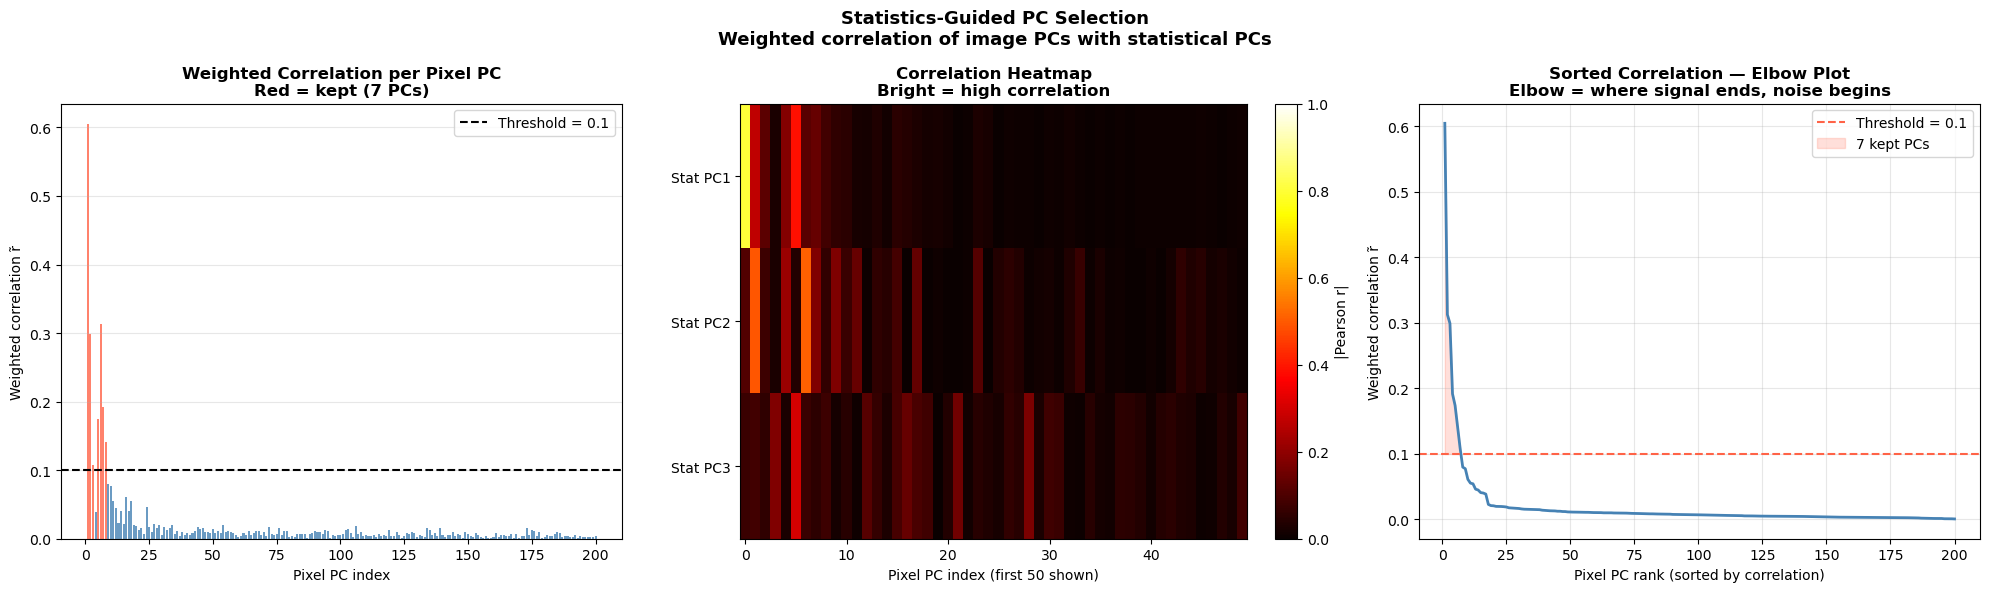

Variance explained by kept PCs: 33.70%


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1 — weighted correlation per pixel PC (bar chart)
colors = ['tomato' if weighted_corr[i] > THRESHOLD else 'steelblue'
          for i in range(N_PIXEL_PCS)]
axes[0].bar(range(1, N_PIXEL_PCS+1), weighted_corr, color=colors, alpha=0.8)
axes[0].axhline(THRESHOLD, color='black', linestyle='--',
                linewidth=1.5, label=f'Threshold = {THRESHOLD}')
axes[0].set_xlabel('Pixel PC index')
axes[0].set_ylabel('Weighted correlation r̃')
axes[0].set_title(f'Weighted Correlation per Pixel PC\nRed = kept ({len(keep_idx)} PCs)',
                  fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3, axis='y')

# Plot 2 — correlation heatmap (pixel PC × stat PC)
im = axes[1].imshow(corr_matrix[:50].T, cmap='hot', aspect='auto', vmin=0, vmax=1)
axes[1].set_xlabel('Pixel PC index (first 50 shown)')
axes[1].set_yticks(range(n_stat_pcs))
axes[1].set_yticklabels([f'Stat PC{k+1}' for k in range(n_stat_pcs)])
axes[1].set_title('Correlation Heatmap\nBright = high correlation',
                  fontweight='bold')
plt.colorbar(im, ax=axes[1], fraction=0.046, label='|Pearson r|')

# Plot 3 — sorted weighted correlation (elbow plot)
sorted_corr = np.sort(weighted_corr)[::-1]
axes[2].plot(range(1, N_PIXEL_PCS+1), sorted_corr,
             color='steelblue', linewidth=2)
axes[2].axhline(THRESHOLD, color='tomato', linestyle='--',
                linewidth=1.5, label=f'Threshold = {THRESHOLD}')
axes[2].fill_between(range(1, len(keep_idx)+1),
                     sorted_corr[:len(keep_idx)], THRESHOLD,
                     alpha=0.2, color='tomato', label=f'{len(keep_idx)} kept PCs')
axes[2].set_xlabel('Pixel PC rank (sorted by correlation)')
axes[2].set_ylabel('Weighted correlation r̃')
axes[2].set_title('Sorted Correlation — Elbow Plot\nElbow = where signal ends, noise begins',
                  fontweight='bold')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle('Statistics-Guided PC Selection\nWeighted correlation of image PCs with statistical PCs',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pc_weighted_correlation.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Variance explained by kept PCs: '
      f'{pca_pixels.explained_variance_ratio_[keep_idx].sum()*100:.2f}%')

## 9. Reconstruct Images from Kept PCs

In [11]:
print(f'Reconstructing all images from {len(keep_idx)} kept PCs...')

# Project onto kept PCs only and reconstruct
kept_components  = pca_pixels.components_[keep_idx]              # (k, 16384)
projections      = (X_pixels - pca_pixels.mean_) @ kept_components.T  # (N, k)
recon_flat       = projections @ kept_components + pca_pixels.mean_    # (N, 16384)
recon_imgs       = recon_flat.reshape(len(x_train), DIM, DIM).astype(np.float32)

# Normalise per image to [0,1]
#recon_imgs = norm_batch(recon_imgs)


print(f'Reconstructed images shape: {recon_imgs.shape}')
print(f'Normal    mean: {recon_imgs[y_ints==0].mean():.4f}')
print(f'Pneumonia mean: {recon_imgs[y_ints==1].mean():.4f}')
print(f'Difference    : {recon_imgs[y_ints==1].mean() - recon_imgs[y_ints==0].mean():.4f}')
print(f'(positive = pneumonia reconstructions are brighter — consolidation signal preserved)')

Reconstructing all images from 7 kept PCs...
Reconstructed images shape: (5216, 128, 128)
Normal    mean: 0.3848
Pneumonia mean: 0.3994
Difference    : 0.0146
(positive = pneumonia reconstructions are brighter — consolidation signal preserved)


## 10. Visual Comparison — Original vs Reconstruction

At least 2 Normal and 2 Pneumonia images shown side by side.

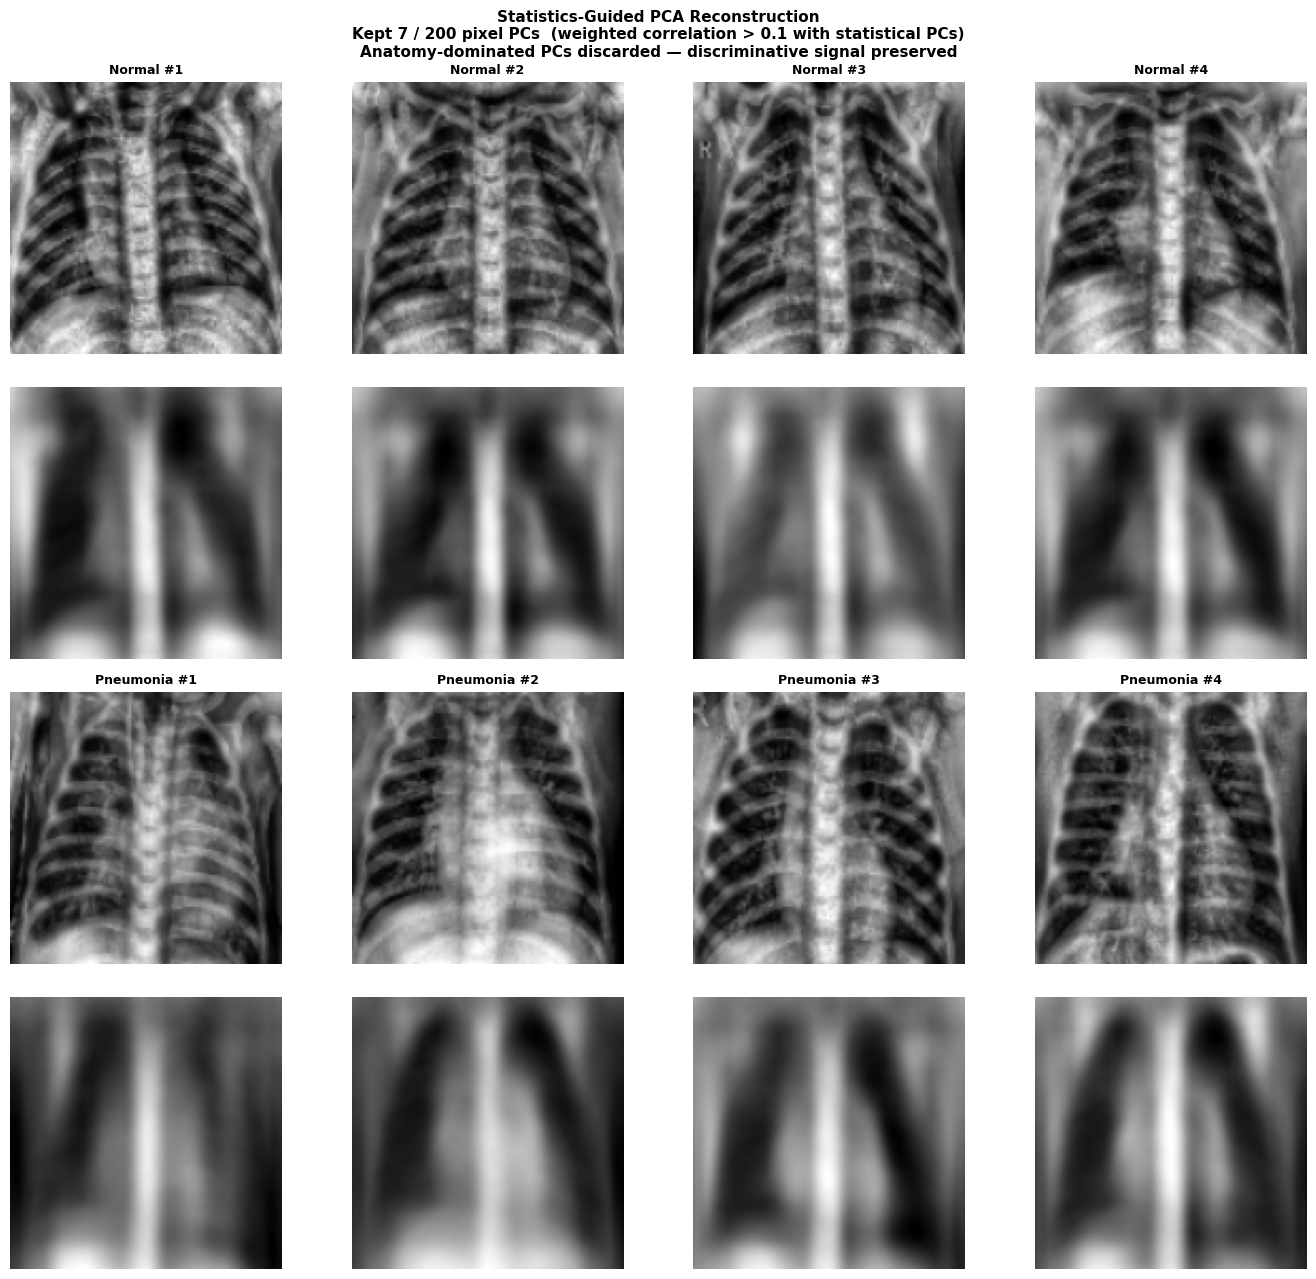

In [12]:
#np.random.seed(42)
N_SHOW  = 4   # number of images per class

n_idx = np.random.choice(np.where(y_ints==0)[0], N_SHOW, replace=False)
p_idx = np.random.choice(np.where(y_ints==1)[0], N_SHOW, replace=False)

fig, axes = plt.subplots(4, N_SHOW, figsize=(N_SHOW*3.5, 13))

row_labels = [
    f'Normal\nOriginal',
    f'Normal\nReconstructed\n({len(keep_idx)} PCs)',
    f'Pneumonia\nOriginal',
    f'Pneumonia\nReconstructed\n({len(keep_idx)} PCs)',
]

for col in range(N_SHOW):
    ni = n_idx[col]
    pi = p_idx[col]

    # Normal original
    axes[0, col].imshow(x_train[ni], cmap='gray')
    axes[0, col].set_title(f'Normal #{col+1}', fontsize=9, fontweight='bold')
    axes[0, col].axis('off')

    # Normal reconstruction
    axes[1, col].imshow(recon_imgs[ni], cmap='gray')
    axes[1, col].axis('off')

    # Pneumonia original
    axes[2, col].imshow(x_train[pi], cmap='gray')
    axes[2, col].set_title(f'Pneumonia #{col+1}', fontsize=9, fontweight='bold')
    axes[2, col].axis('off')

    # Pneumonia reconstruction
    axes[3, col].imshow(recon_imgs[pi], cmap='gray')
    axes[3, col].axis('off')

for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label, fontsize=9, fontweight='bold')

plt.suptitle(
    f'Statistics-Guided PCA Reconstruction\n'
    f'Kept {len(keep_idx)} / {N_PIXEL_PCS} pixel PCs  '
    f'(weighted correlation > {THRESHOLD} with statistical PCs)\n'
    f'Anatomy-dominated PCs discarded — discriminative signal preserved',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('stats_guided_reconstruction.png', dpi=200, bbox_inches='tight')
plt.show()

## 11. Difference Maps — What Was Removed

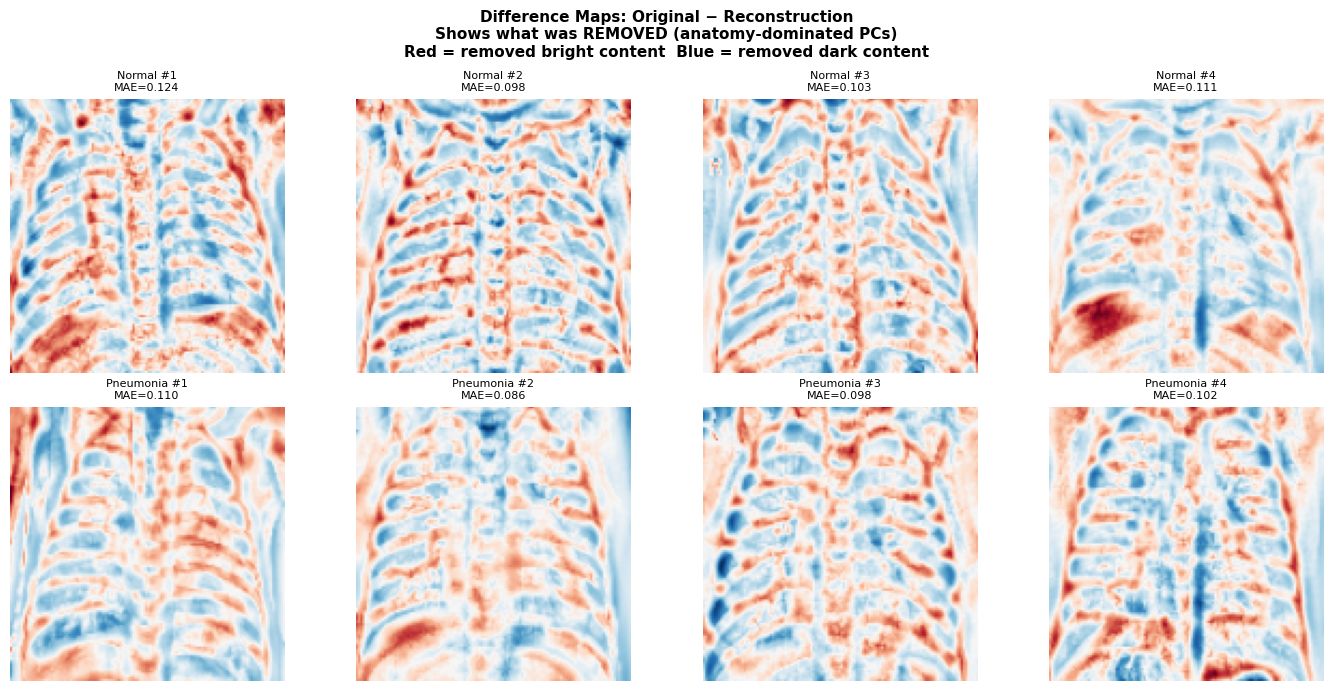

In [13]:
# Difference = original - reconstruction = anatomy + noise that was discarded
fig, axes = plt.subplots(2, N_SHOW, figsize=(N_SHOW*3.5, 7))

for col in range(N_SHOW):
    for row, (idx, label) in enumerate([(n_idx[col],'Normal'), (p_idx[col],'Pneumonia')]):
        diff = x_train[idx] - recon_imgs[idx]
        vmax = np.abs(diff).max()
        axes[row, col].imshow(diff, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        axes[row, col].set_title(f'{label} #{col+1}\nMAE={np.abs(diff).mean():.3f}',
                                  fontsize=8)
        axes[row, col].axis('off')

axes[0, 0].set_ylabel('Normal\nOriginal − Recon', fontsize=9, fontweight='bold')
axes[1, 0].set_ylabel('Pneumonia\nOriginal − Recon', fontsize=9, fontweight='bold')

plt.suptitle('Difference Maps: Original − Reconstruction\n'
             'Shows what was REMOVED (anatomy-dominated PCs)\n'
             'Red = removed bright content  Blue = removed dark content',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('difference_maps.png', dpi=200, bbox_inches='tight')
plt.show()

## 12. Class Separation Check

Does the reconstruction preserve the class-discriminative signal?

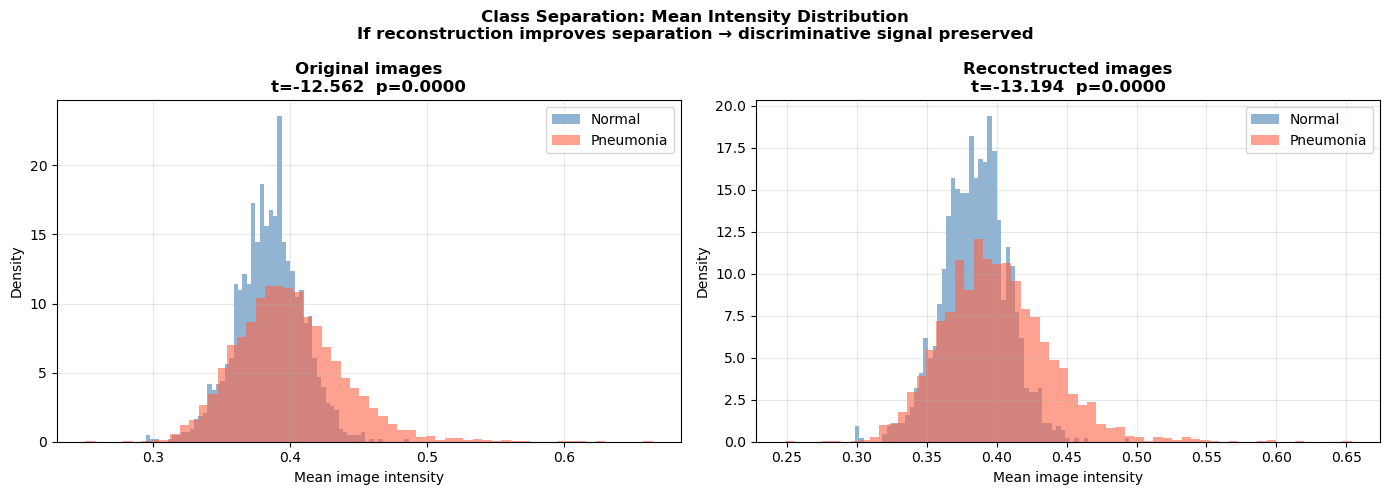

Original   : Normal mean = 0.3851  Pneumonia mean = 0.3992  Δ = 0.0141
Reconstruct: Normal mean = 0.3848  Pneumonia mean = 0.3994  Δ = 0.0146

If Δ increased after reconstruction → signal preserved
If Δ decreased → some signal was in the discarded PCs (lower threshold)


In [14]:
from scipy.stats import ttest_ind

# Per-image mean intensity — should separate more cleanly after reconstruction
orig_mean_n = x_train[y_ints==0].mean(axis=(1,2))
orig_mean_p = x_train[y_ints==1].mean(axis=(1,2))
recon_mean_n = recon_imgs[y_ints==0].mean(axis=(1,2))
recon_mean_p = recon_imgs[y_ints==1].mean(axis=(1,2))

t_orig,  p_orig  = ttest_ind(orig_mean_n,  orig_mean_p)
t_recon, p_recon = ttest_ind(recon_mean_n, recon_mean_p)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (mn, mp, t, p, title) in zip(axes, [
    (orig_mean_n,  orig_mean_p,  t_orig,  p_orig,  'Original images'),
    (recon_mean_n, recon_mean_p, t_recon, p_recon, 'Reconstructed images'),
]):
    ax.hist(mn, bins=60, color='steelblue', alpha=0.6, density=True, label='Normal')
    ax.hist(mp, bins=60, color='tomato',    alpha=0.6, density=True, label='Pneumonia')
    ax.set_title(f'{title}\nt={t:.3f}  p={p:.4f}', fontweight='bold')
    ax.set_xlabel('Mean image intensity'); ax.set_ylabel('Density')
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Class Separation: Mean Intensity Distribution\n'
             'If reconstruction improves separation → discriminative signal preserved',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('class_separation_check.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Original   : Normal mean = {orig_mean_n.mean():.4f}  '
      f'Pneumonia mean = {orig_mean_p.mean():.4f}  '
      f'Δ = {orig_mean_p.mean()-orig_mean_n.mean():.4f}')
print(f'Reconstruct: Normal mean = {recon_mean_n.mean():.4f}  '
      f'Pneumonia mean = {recon_mean_p.mean():.4f}  '
      f'Δ = {recon_mean_p.mean()-recon_mean_n.mean():.4f}')
print(f'\nIf Δ increased after reconstruction → signal preserved')
print(f'If Δ decreased → some signal was in the discarded PCs (lower threshold)')

## 13. Summary & Next Step

In [15]:
print('=' * 60)
print('STATISTICS-GUIDED PCA SUMMARY')
print('=' * 60)
print(f'Resolution           : {DIM}×{DIM}')
print(f'Statistics used      : {STAT_NAMES}')
print(f'Statistical PCs kept : {n_stat_pcs} (95% of statistics variance)')
print(f'Pixel PCs fitted     : {N_PIXEL_PCS}')
print(f'Correlation threshold: {THRESHOLD}')
print(f'Pixel PCs kept       : {len(keep_idx)} — {list(keep_idx+1)}')
print(f'Variance kept        : {pca_pixels.explained_variance_ratio_[keep_idx].sum()*100:.2f}%')
print()
print(f'Normal    recon mean : {recon_imgs[y_ints==0].mean():.4f}')
print(f'Pneumonia recon mean : {recon_imgs[y_ints==1].mean():.4f}')
print()
print('Next step: apply Gabor encoder to reconstructed images')
print('  → recon_imgs is ready for gabor_THIS(recon_imgs, GM1, GM2)')
print('=' * 60)

STATISTICS-GUIDED PCA SUMMARY
Resolution           : 128×128
Statistics used      : ['lower_mean', 'low_high_ratio', 'lower_std', 'global_mean', 'dc_power']
Statistical PCs kept : 3 (95% of statistics variance)
Pixel PCs fitted     : 200
Correlation threshold: 0.1
Pixel PCs kept       : 7 — [np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
Variance kept        : 33.70%

Normal    recon mean : 0.3848
Pneumonia recon mean : 0.3994

Next step: apply Gabor encoder to reconstructed images
  → recon_imgs is ready for gabor_THIS(recon_imgs, GM1, GM2)


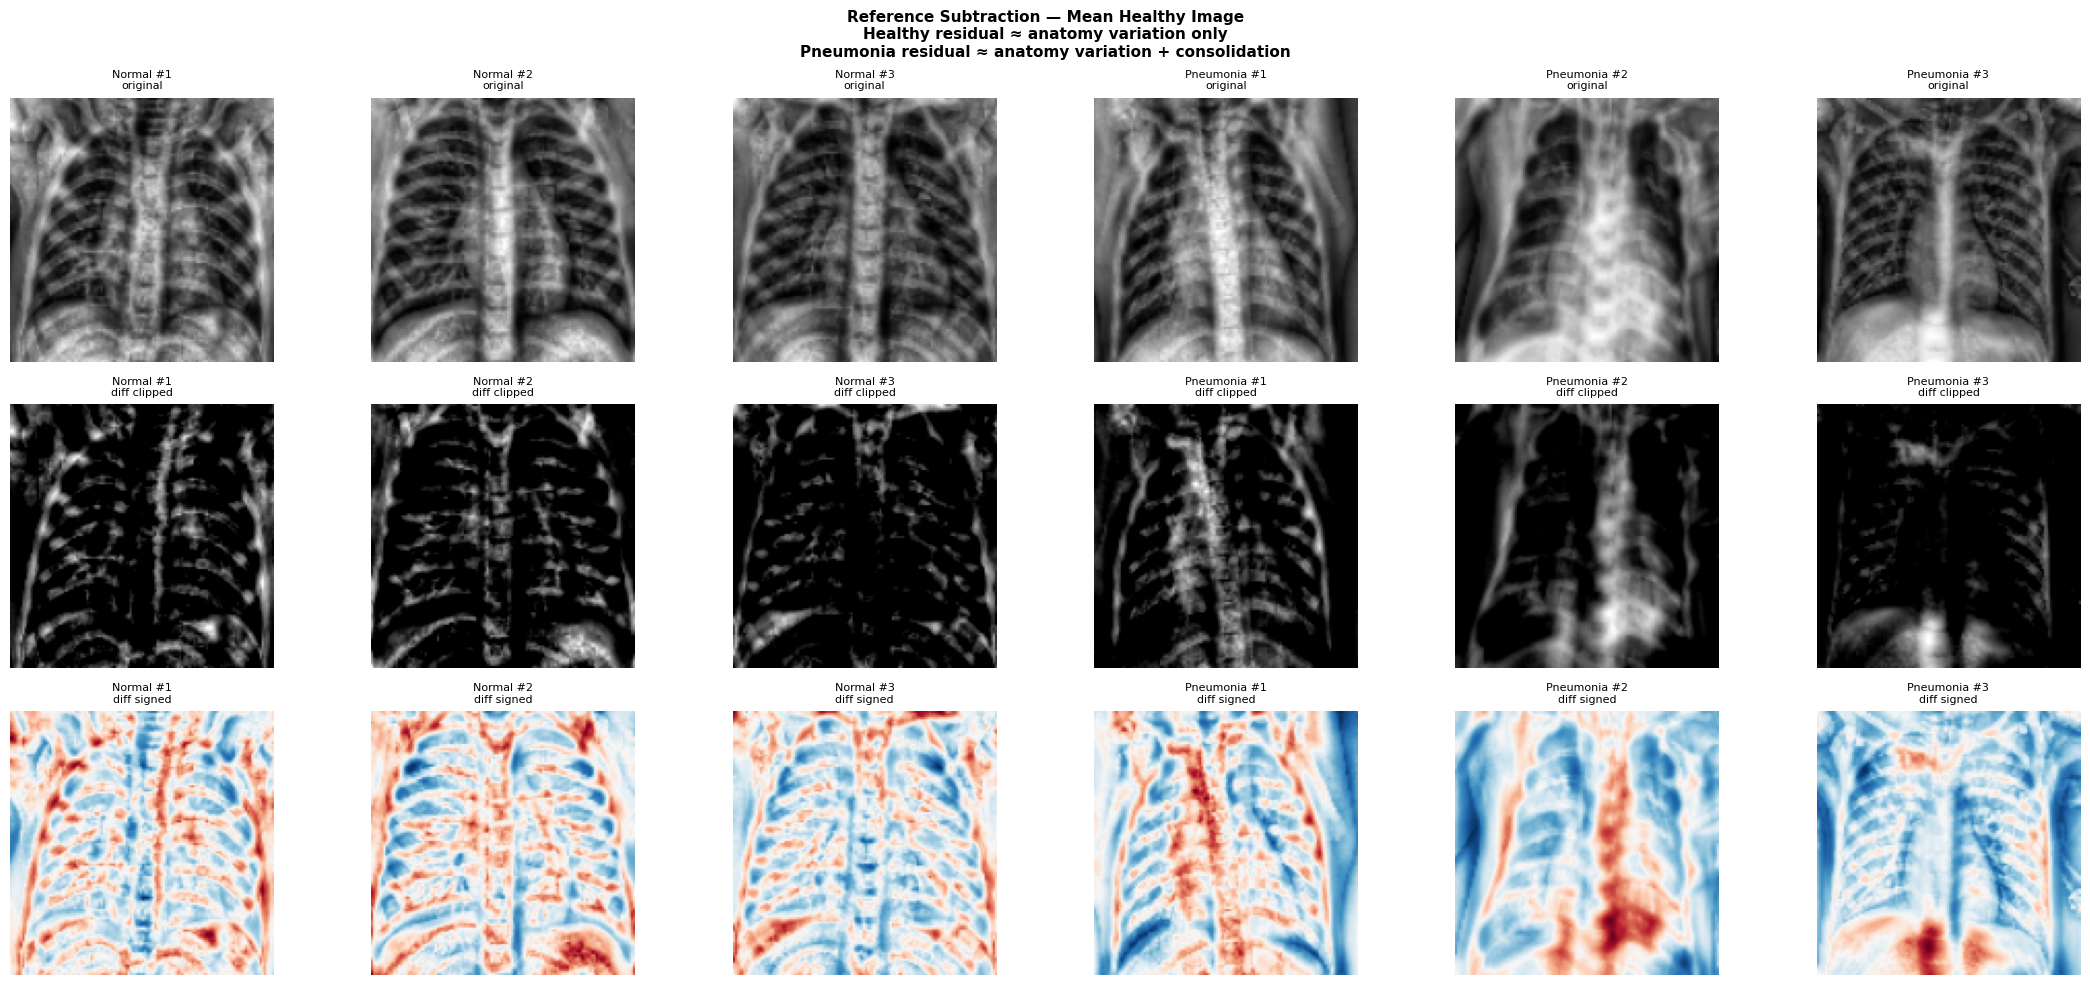

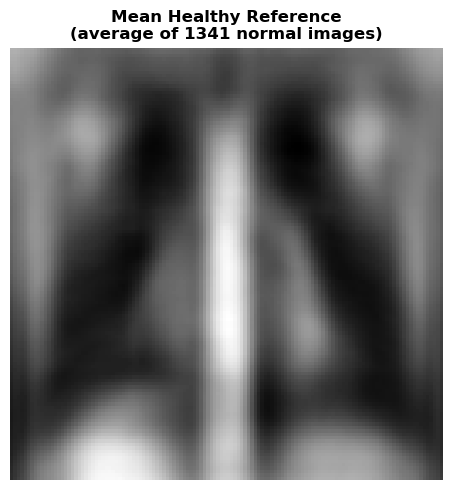

Using difference maps as input to pixel PCA
X_pixels shape: (5216, 16384)
Normal    mean: 0.1154
Pneumonia mean: 0.1394
Difference    : 0.0240
(positive and larger than raw images = reference subtraction amplified the signal)


In [16]:
# ── Add after Cell 3 (preprocessing) ─────────────────────────────────────────

# Compute mean healthy reference
mean_healthy  = x_train[y_ints == 0].mean(axis=0).astype(np.float32)  # (128, 128)

# Subtract from all images
X_diff        = x_train - mean_healthy[np.newaxis]    # (N, 128, 128)

# Two options for handling negatives:
# Option A — clip negatives to zero (keep only positive deviations from healthy)
# Healthy images: residual ≈ 0 (they look like the mean)
# Pneumonia images: residual > 0 where consolidation exists
X_diff_clipped = np.clip(X_diff, 0, None).astype(np.float32)

# Option B — keep full signed difference (captures both brighter and darker regions)
# More information preserved but normal images also have non-zero residuals
X_diff_signed  = X_diff.copy()

# Normalise per image to [0,1]
def norm_batch(X):
    mn = X.min(axis=(1,2), keepdims=True)
    mx = X.max(axis=(1,2), keepdims=True)
    return (X - mn) / (mx - mn + 1e-8)

X_diff_clipped = norm_batch(X_diff_clipped)
X_diff_signed  = norm_batch(X_diff_signed)

# Visual check — does the difference map look reasonable?
np.random.seed(42)
n_idx = np.random.choice(np.where(y_ints==0)[0], 3, replace=False)
p_idx = np.random.choice(np.where(y_ints==1)[0], 3, replace=False)

fig, axes = plt.subplots(3, 6, figsize=(22, 10))
row_labels = ['Original', 'Diff (clipped)', 'Diff (signed)']

for col in range(3):
    for row, (imgs, idx) in enumerate([
        (x_train,        [n_idx[col], p_idx[col]]),
    ]):
        pass

for col in range(3):
    ni = n_idx[col]; pi = p_idx[col]
    
    # Normal
    axes[0, col].imshow(x_train[ni],          cmap='gray')
    axes[0, col].set_title(f'Normal #{col+1}\noriginal', fontsize=8)
    axes[0, col].axis('off')
    
    axes[1, col].imshow(X_diff_clipped[ni],   cmap='gray')
    axes[1, col].set_title(f'Normal #{col+1}\ndiff clipped', fontsize=8)
    axes[1, col].axis('off')
    
    axes[2, col].imshow(X_diff_signed[ni],    cmap='RdBu_r')
    axes[2, col].set_title(f'Normal #{col+1}\ndiff signed', fontsize=8)
    axes[2, col].axis('off')
    
    # Pneumonia
    axes[0, col+3].imshow(x_train[pi],        cmap='gray')
    axes[0, col+3].set_title(f'Pneumonia #{col+1}\noriginal', fontsize=8)
    axes[0, col+3].axis('off')
    
    axes[1, col+3].imshow(X_diff_clipped[pi], cmap='gray')
    axes[1, col+3].set_title(f'Pneumonia #{col+1}\ndiff clipped', fontsize=8)
    axes[1, col+3].axis('off')
    
    axes[2, col+3].imshow(X_diff_signed[pi],  cmap='RdBu_r')
    axes[2, col+3].set_title(f'Pneumonia #{col+1}\ndiff signed', fontsize=8)
    axes[2, col+3].axis('off')

axes[0, 0].set_ylabel('Original',      fontsize=9, fontweight='bold')
axes[1, 0].set_ylabel('Diff clipped\n(+ve only)', fontsize=9, fontweight='bold')
axes[2, 0].set_ylabel('Diff signed',   fontsize=9, fontweight='bold')

plt.suptitle('Reference Subtraction — Mean Healthy Image\n'
             'Healthy residual ≈ anatomy variation only\n'
             'Pneumonia residual ≈ anatomy variation + consolidation',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('reference_subtraction.png', dpi=200, bbox_inches='tight')
plt.show()

# Mean reference image
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(mean_healthy, cmap='gray')
ax.set_title(f'Mean Healthy Reference\n(average of {(y_ints==0).sum()} normal images)',
             fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

# ── Replace X_pixels with X_diff for the rest of the pipeline ─────────────────
# Use clipped version — only positive deviations from healthy are meaningful
# for consolidation detection
X_pixels = X_diff_clipped.reshape(len(X_diff_clipped), -1).astype(np.float32)
print(f'Using difference maps as input to pixel PCA')
print(f'X_pixels shape: {X_pixels.shape}')
print(f'Normal    mean: {X_diff_clipped[y_ints==0].mean():.4f}')
print(f'Pneumonia mean: {X_diff_clipped[y_ints==1].mean():.4f}')
print(f'Difference    : {X_diff_clipped[y_ints==1].mean()-X_diff_clipped[y_ints==0].mean():.4f}')
print(f'(positive and larger than raw images = reference subtraction amplified the signal)')

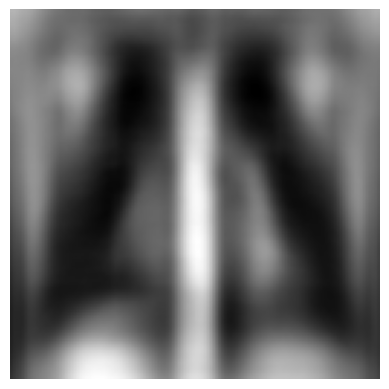

In [17]:
recon_healthy = recon_imgs[np.where(y_ints==0)[0]]
recon_unhealthy = recon_imgs[np.where(y_ints==1)[0]]

reference_img = np.mean(recon_healthy, axis=0)

plt.imshow(reference_img, cmap='gray')
plt.axis('off')
plt.show()

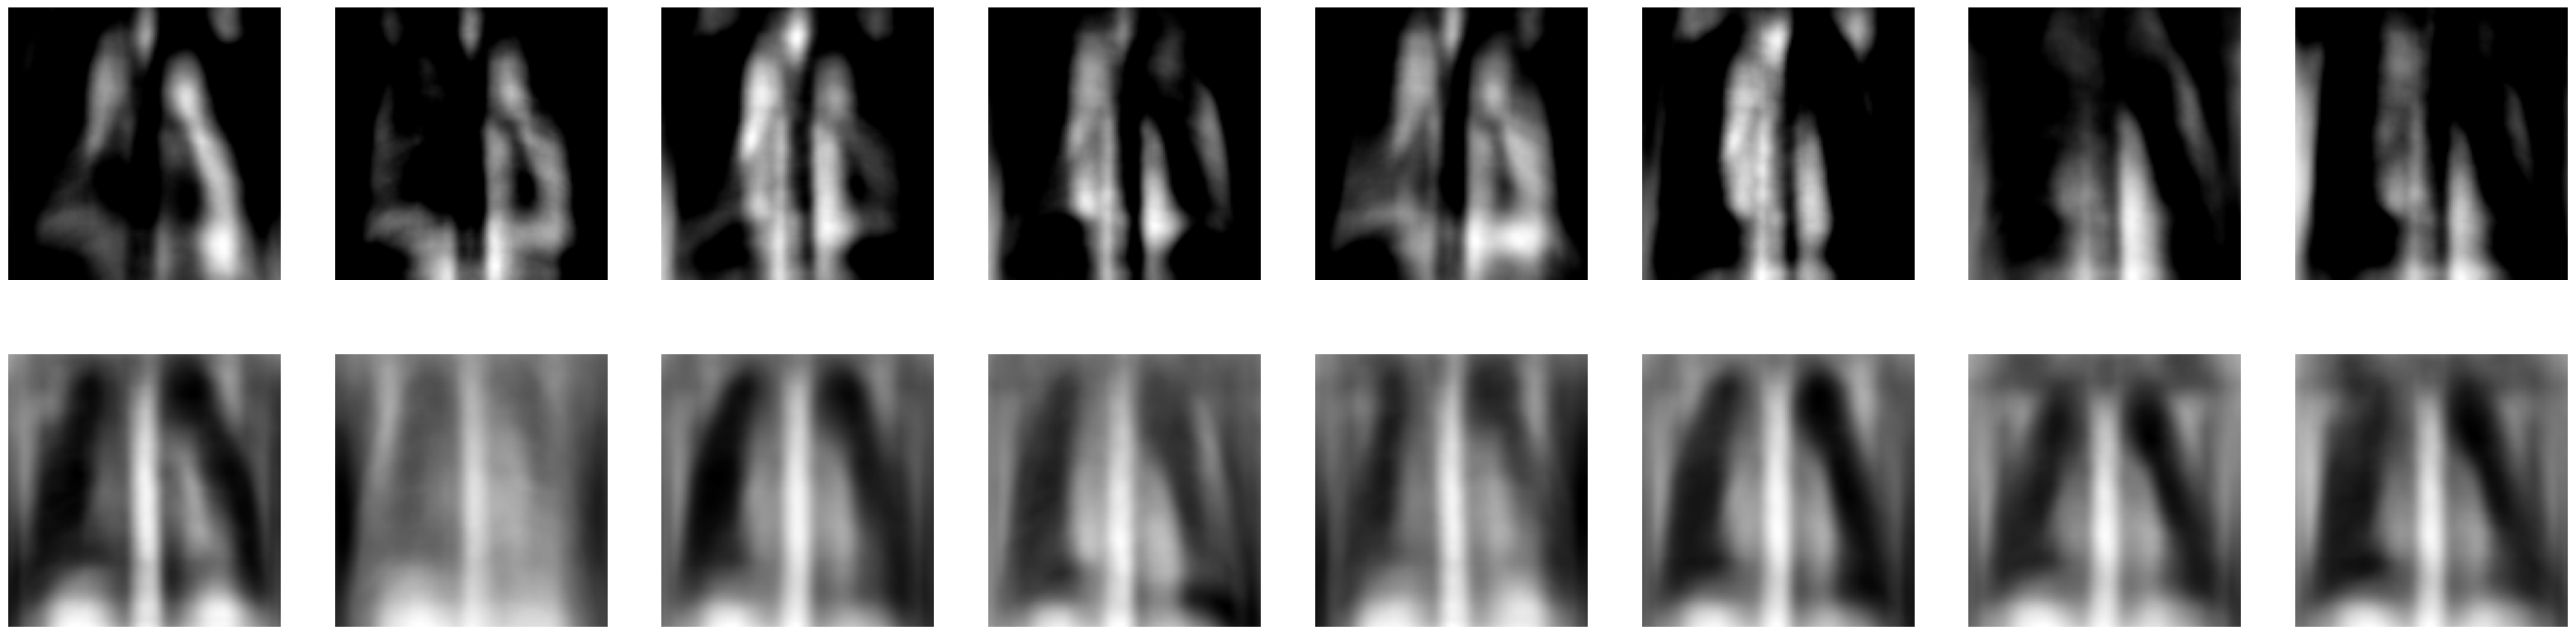

In [18]:
speckles = np.zeros(recon_unhealthy.shape)

for i in range(len(speckles)):
    speckles[i] = np.maximum(recon_unhealthy[i] - reference_img, 0)

fig, axes = plt.subplots(2, 8, figsize=(40, 10))

n_idx = np.random.choice(np.linspace(0, len(speckles), len(speckles) + 1), 8, replace=False)


for i in range(8):
    axes[0, i].imshow(speckles[int(n_idx[i])], cmap='gray')
    axes[0, i].axis('off')

    axes[1, i].imshow(recon_unhealthy[int(n_idx[i])], cmap='gray')
    axes[1, i].axis('off')
    
plt.show()

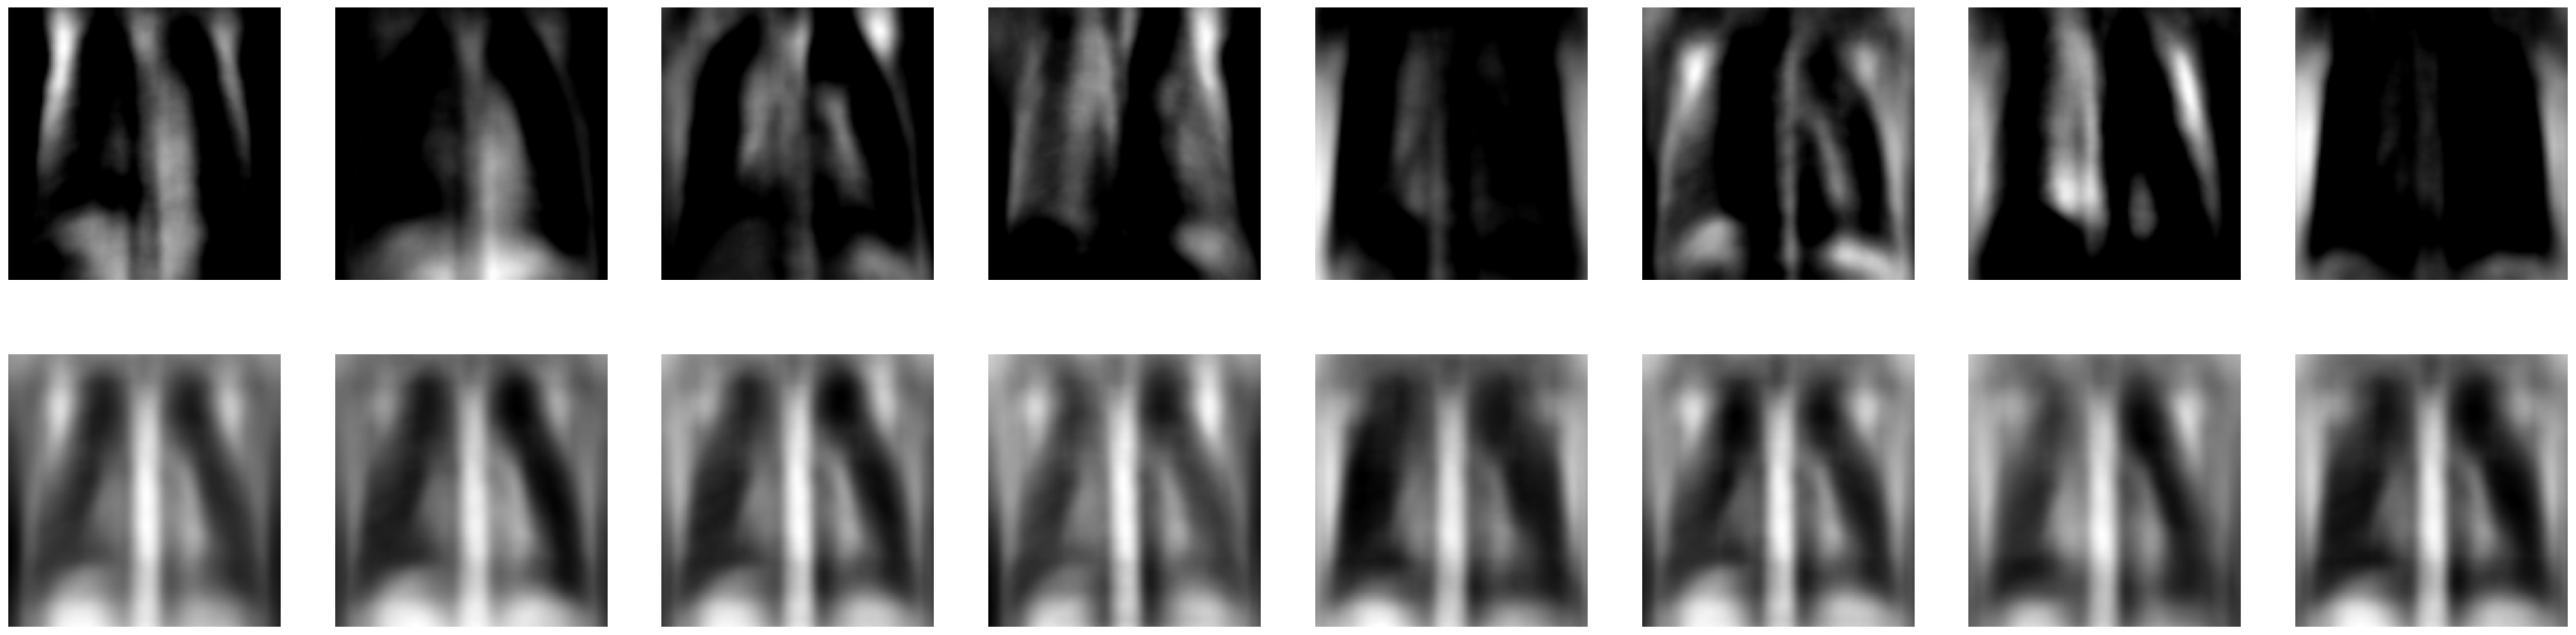

In [19]:
healthy_diff = np.zeros(recon_healthy.shape)

for i in range(len(healthy_diff)):
    healthy_diff[i] = np.maximum(recon_healthy[i] - reference_img, 0)

fig, axes = plt.subplots(2, 8, figsize=(40, 10))

n_idx = np.random.choice(len(healthy_diff), 8, replace=False)


for i in range(8):
    axes[0, i].imshow(healthy_diff[int(n_idx[i])], cmap='gray')
    axes[0, i].axis('off')

    axes[1, i].imshow(recon_healthy[int(n_idx[i])], cmap='gray')
    axes[1, i].axis('off')
    
plt.show()

In [20]:
# Mean intensity per image — one value per image
mu_per_image = recon_imgs.mean(axis=(1,2)) # shape (N,)

# Average mean intensity per class
mu_normal    = recon_imgs[y_ints==0].mean(axis=(1,2)).mean()  # scalar
mu_pneumonia = recon_imgs[y_ints==1].mean(axis=(1,2)).mean()  # scalar

# Which is equivalent to
mu_normal    = recon_imgs[y_ints==0].mean()   # mean of all pixels of all normal images
mu_pneumonia = recon_imgs[y_ints==1].mean()   # mean of all pixels of all pneumonia images

print(mu_normal)
print(mu_pneumonia)

0.38478848
0.39936864


Mean residual:
  Normal    : 0.02705
  Pneumonia : 0.05531
  Difference: 0.02825

Compare to raw reconstruction difference: 0.01462
If residual difference > reconstruction difference
→ reference subtraction amplified the signal


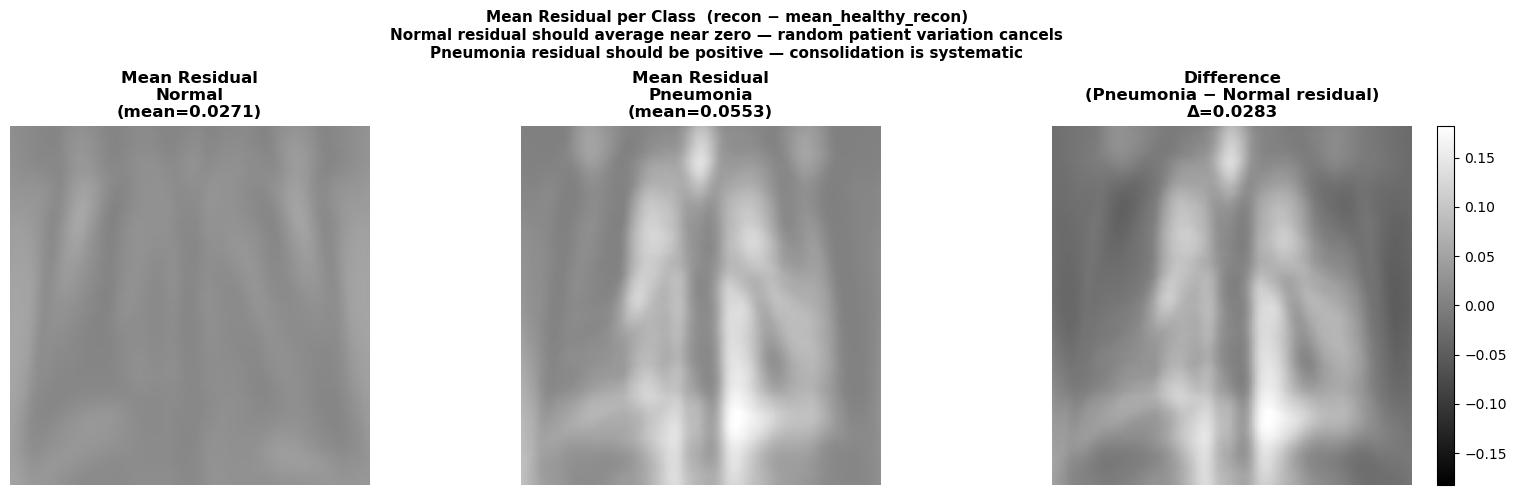

In [21]:
# Reference — mean of reconstructed healthy images
reference_img = recon_imgs[y_ints == 0].mean(axis=0)   # (128, 128)

# Residuals — signed difference from reference
residual_all       = np.maximum(recon_imgs - reference_img[np.newaxis], 0)  # (N, 128, 128)

residual_normal    = residual_all[y_ints == 0]   # (N_n, 128, 128)
residual_pneumonia = residual_all[y_ints == 1]   # (N_p, 128, 128)

# Mean residual per class — scalar
mean_res_normal    = residual_normal.mean()
mean_res_pneumonia = residual_pneumonia.mean()

print(f'Mean residual:')
print(f'  Normal    : {mean_res_normal:.5f}')
print(f'  Pneumonia : {mean_res_pneumonia:.5f}')
print(f'  Difference: {mean_res_pneumonia - mean_res_normal:.5f}')
print()
print(f'Compare to raw reconstruction difference: 0.01462')
print(f'If residual difference > reconstruction difference')
print(f'→ reference subtraction amplified the signal')

# Mean spatial residual image per class
mean_spatial_normal    = residual_normal.mean(axis=0)    # (128, 128)
mean_spatial_pneumonia = residual_pneumonia.mean(axis=0) # (128, 128)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

vmax = max(np.abs(mean_spatial_normal).max(),
           np.abs(mean_spatial_pneumonia).max())

axes[0].imshow(mean_spatial_normal,    cmap='gray', vmin=-vmax, vmax=vmax)
axes[0].set_title(f'Mean Residual\nNormal\n(mean={mean_res_normal:.4f})',
                   fontweight='bold')
axes[0].axis('off')

axes[1].imshow(mean_spatial_pneumonia, cmap='gray', vmin=-vmax, vmax=vmax)
axes[1].set_title(f'Mean Residual\nPneumonia\n(mean={mean_res_pneumonia:.4f})',
                   fontweight='bold')
axes[1].axis('off')

# Difference between class mean residuals
diff = mean_spatial_pneumonia - mean_spatial_normal
vmax_diff = np.abs(diff).max()
im = axes[2].imshow(diff, cmap='gray', vmin=-vmax_diff, vmax=vmax_diff)
axes[2].set_title(f'Difference\n(Pneumonia − Normal residual)\n'
                   f'Δ={mean_res_pneumonia - mean_res_normal:.4f}',
                   fontweight='bold')
axes[2].axis('off')
plt.colorbar(im, ax=axes[2], fraction=0.046)

plt.suptitle('Mean Residual per Class  (recon − mean_healthy_recon)\n'
             'Normal residual should average near zero — random patient variation cancels\n'
             'Pneumonia residual should be positive — consolidation is systematic',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('mean_residual_per_class.png', dpi=200, bbox_inches='tight')
plt.show()

In [22]:
from scipy.stats import ttest_ind, mannwhitneyu

res_mean_n = residual_all[y_ints==0].mean(axis=(1,2))  # one value per image
res_mean_p = residual_all[y_ints==1].mean(axis=(1,2))

fisher = (res_mean_p.mean() - res_mean_n.mean())**2 / \
         (res_mean_p.std()**2 + res_mean_n.std()**2 + 1e-8)

print(f'Fisher ratio on residuals: {fisher:.4f}')
print(f'Compare to raw statistics Fisher ratios:')
print(f'  lower_mean     : 0.67')
print(f'  low_high_ratio : 0.87')

Fisher ratio on residuals: 0.7430
Compare to raw statistics Fisher ratios:
  lower_mean     : 0.67
  low_high_ratio : 0.87


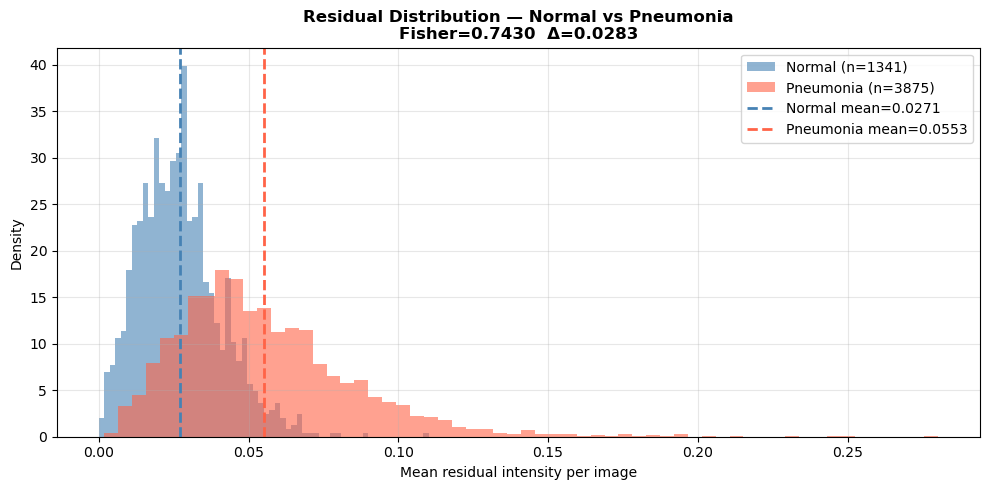

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(res_mean_n, bins=60, color='steelblue',
        alpha=0.6, density=True, label=f'Normal (n={len(res_mean_n)})')
ax.hist(res_mean_p, bins=60, color='tomato',
        alpha=0.6, density=True, label=f'Pneumonia (n={len(res_mean_p)})')
ax.axvline(res_mean_n.mean(), color='steelblue', linestyle='--',
           linewidth=2, label=f'Normal mean={res_mean_n.mean():.4f}')
ax.axvline(res_mean_p.mean(), color='tomato',    linestyle='--',
           linewidth=2, label=f'Pneumonia mean={res_mean_p.mean():.4f}')
ax.set_xlabel('Mean residual intensity per image')
ax.set_ylabel('Density')
ax.set_title(f'Residual Distribution — Normal vs Pneumonia\n'
              f'Fisher={fisher:.4f}  Δ={res_mean_p.mean()-res_mean_n.mean():.4f}',
              fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
print(len(speckles))

3875
